# Argon saturation-property analysis

This notebook loads `argon_saturation.tsv`, downloaded from the [NIST Chemistry WebBook](https://webbook.nist.gov/chemistry/fluid/), validates the table, assigns concise column names, plots the main saturation properties, and provides interpolation helpers for simulation inputs.

The source query covers **85–140 K** in **0.1 K** increments. A suffix of `liquid` or `vapor` identifies the saturated phase.

In [39]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

## Load and validate the NIST table

In [40]:
data_path = Path("argon_saturation.tsv")
if not data_path.exists():
    raise FileNotFoundError(
        f"Could not find {data_path.resolve()}. Start Jupyter from the repository root, "
        "or change data_path to the file's location."
    )

raw = pd.read_csv(data_path, sep="\t")
print(f"Loaded {raw.shape[0]} rows and {raw.shape[1]} columns from {data_path}")
raw.head()

Loaded 551 rows and 25 columns from argon_saturation.tsv


,Temperature (K),Pressure (bar),"Density (l, mol/l)","Volume (l, l/mol)","Internal Energy (l, kJ/mol)","Enthalpy (l, kJ/mol)","Entropy (l, J/mol*K)","Cv (l, J/mol*K)","Cp (l, J/mol*K)","Sound Spd. (l, m/s)","Joule-Thomson (l, K/bar)","Viscosity (l, uPa*s)","Therm. Cond. (l, W/m*K)","Surf. Tension (l, N/m)","Density (v, mol/l)","Volume (v, l/mol)","Internal Energy (v, kJ/mol)","Enthalpy (v, kJ/mol)","Entropy (v, J/mol*K)","Cv (v, J/mol*K)","Cp (v, J/mol*K)","Sound Spd. (v, m/s)","Joule-Thomson (v, K/bar)","Viscosity (v, uPa*s)","Therm. Cond. (v, W/m*K)"
0,85.0,0.78897,35.284,0.028342,-4.8000,-4.7977,53.740,21.764,44.571,854.24,-0.040120,279.46,0.13191,0.013106,0.11492,8.7019,1.0212,1.7078,130.28,13.015,22.310,169.08,3.4706,6.9622,0.005449
1,85.1,0.79783,35.268,0.028354,-4.7955,-4.7933,53.792,21.748,44.573,853.55,-0.040087,278.59,0.13176,0.013081,0.11610,8.6133,1.0221,1.7093,130.20,13.019,22.322,169.16,3.4624,6.9711,0.005456
2,85.2,0.80677,35.253,0.028366,-4.7911,-4.7888,53.844,21.732,44.574,852.87,-0.040053,277.72,0.13161,0.013056,0.11729,8.5259,1.0230,1.7109,130.13,13.022,22.334,169.24,3.4542,6.9801,0.005464
3,85.3,0.81578,35.238,0.028379,-4.7866,-4.7843,53.896,21.717,44.575,852.18,-0.040018,276.86,0.13147,0.013031,0.11849,8.4395,1.0239,1.7124,130.06,13.026,22.346,169.32,3.4461,6.9890,0.005471
4,85.4,0.82488,35.222,0.028391,-4.7822,-4.7799,53.948,21.701,44.577,851.49,-0.039983,276.00,0.13132,0.013006,0.11970,8.3542,1.0248,1.7139,129.99,13.030,22.359,169.40,3.4380,6.9980,0.005479


In [41]:
column_names = [
    "temperature_K",
    "pressure_bar",
    "density_liquid_mol_L",
    "volume_liquid_L_mol",
    "internal_energy_liquid_kJ_mol",
    "enthalpy_liquid_kJ_mol",
    "entropy_liquid_J_mol_K",
    "cv_liquid_J_mol_K",
    "cp_liquid_J_mol_K",
    "sound_speed_liquid_m_s",
    "joule_thomson_liquid_K_bar",
    "viscosity_liquid_uPa_s",
    "thermal_conductivity_liquid_W_m_K",
    "surface_tension_N_m",
    "density_vapor_mol_L",
    "volume_vapor_L_mol",
    "internal_energy_vapor_kJ_mol",
    "enthalpy_vapor_kJ_mol",
    "entropy_vapor_J_mol_K",
    "cv_vapor_J_mol_K",
    "cp_vapor_J_mol_K",
    "sound_speed_vapor_m_s",
    "joule_thomson_vapor_K_bar",
    "viscosity_vapor_uPa_s",
    "thermal_conductivity_vapor_W_m_K",
]

if raw.shape[1] != len(column_names):
    raise ValueError(f"Expected {len(column_names)} NIST columns, found {raw.shape[1]}")

df = raw.copy()
df.columns = column_names
df = df.apply(pd.to_numeric, errors="raise")

assert df["temperature_K"].is_monotonic_increasing
assert not df.isna().any().any()
print(f"Temperature range: {df.temperature_K.min():.1f}–{df.temperature_K.max():.1f} K")
print(f"Missing values: {df.isna().sum().sum()}")
df.head()

Temperature range: 85.0–140.0 K
Missing values: 0


,temperature_K,pressure_bar,density_liquid_mol_L,volume_liquid_L_mol,internal_energy_liquid_kJ_mol,enthalpy_liquid_kJ_mol,entropy_liquid_J_mol_K,cv_liquid_J_mol_K,cp_liquid_J_mol_K,sound_speed_liquid_m_s,joule_thomson_liquid_K_bar,viscosity_liquid_uPa_s,thermal_conductivity_liquid_W_m_K,surface_tension_N_m,density_vapor_mol_L,volume_vapor_L_mol,internal_energy_vapor_kJ_mol,enthalpy_vapor_kJ_mol,entropy_vapor_J_mol_K,cv_vapor_J_mol_K,cp_vapor_J_mol_K,sound_speed_vapor_m_s,joule_thomson_vapor_K_bar,viscosity_vapor_uPa_s,thermal_conductivity_vapor_W_m_K
0,85.0,0.78897,35.284,0.028342,-4.8000,-4.7977,53.740,21.764,44.571,854.24,-0.040120,279.46,0.13191,0.013106,0.11492,8.7019,1.0212,1.7078,130.28,13.015,22.310,169.08,3.4706,6.9622,0.005449
1,85.1,0.79783,35.268,0.028354,-4.7955,-4.7933,53.792,21.748,44.573,853.55,-0.040087,278.59,0.13176,0.013081,0.11610,8.6133,1.0221,1.7093,130.20,13.019,22.322,169.16,3.4624,6.9711,0.005456
2,85.2,0.80677,35.253,0.028366,-4.7911,-4.7888,53.844,21.732,44.574,852.87,-0.040053,277.72,0.13161,0.013056,0.11729,8.5259,1.0230,1.7109,130.13,13.022,22.334,169.24,3.4542,6.9801,0.005464
3,85.3,0.81578,35.238,0.028379,-4.7866,-4.7843,53.896,21.717,44.575,852.18,-0.040018,276.86,0.13147,0.013031,0.11849,8.4395,1.0239,1.7124,130.06,13.026,22.346,169.32,3.4461,6.9890,0.005471
4,85.4,0.82488,35.222,0.028391,-4.7822,-4.7799,53.948,21.701,44.577,851.49,-0.039983,276.00,0.13132,0.013006,0.11970,8.3542,1.0248,1.7139,129.99,13.030,22.359,169.40,3.4380,6.9980,0.005479


## Add useful derived quantities

NIST reports pressure in bar and molar density in mol/L for this query. The following columns convert those values to SI and compute the saturated enthalpy of vaporization.

In [42]:
ARGON_MOLAR_MASS_KG_MOL = 39.948e-3

df["pressure_Pa"] = df["pressure_bar"] * 1e5
df["density_liquid_kg_m3"] = (
    df["density_liquid_mol_L"] * 1000 * ARGON_MOLAR_MASS_KG_MOL
)
df["density_vapor_kg_m3"] = (
    df["density_vapor_mol_L"] * 1000 * ARGON_MOLAR_MASS_KG_MOL
)
df["enthalpy_vaporization_kJ_mol"] = (
    df["enthalpy_vapor_kJ_mol"] - df["enthalpy_liquid_kJ_mol"]
)

df[[
    "temperature_K", "pressure_bar", "pressure_Pa",
    "density_liquid_kg_m3", "density_vapor_kg_m3",
    "surface_tension_N_m", "enthalpy_vaporization_kJ_mol",
]].head()

,temperature_K,pressure_bar,pressure_Pa,density_liquid_kg_m3,density_vapor_kg_m3,surface_tension_N_m,enthalpy_vaporization_kJ_mol
0,85.0,0.78897,78897.0,1409.525232,4.590824,0.013106,6.5055
1,85.1,0.79783,79783.0,1408.886064,4.637963,0.013081,6.5026
2,85.2,0.80677,80677.0,1408.286844,4.685501,0.013056,6.4997
3,85.3,0.81578,81578.0,1407.687624,4.733439,0.013031,6.4967
4,85.4,0.82488,82488.0,1407.048456,4.781776,0.013006,6.4938


## Quick numerical summary

In [43]:
summary_columns = [
    "temperature_K",
    "pressure_bar",
    "density_liquid_kg_m3",
    "density_vapor_kg_m3",
    "surface_tension_N_m",
    "enthalpy_vaporization_kJ_mol",
]
df[summary_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
temperature_K,551.0,112.500000,15.920427,85.000000,98.750000,112.500000,126.250000,140.000000
pressure_bar,551.0,10.611148,8.846912,0.788970,2.928100,7.806500,16.858500,31.682000
density_liquid_kg_m3,551.0,1209.561204,130.085999,943.691604,1105.960380,1223.767032,1322.099034,1409.525232
density_vapor_kg_m3,551.0,54.983751,47.311974,4.590824,15.353015,38.851427,84.721718,178.859180
surface_tension_N_m,551.0,0.006840,0.003434,0.001354,0.003808,0.006653,0.009771,0.013106
enthalpy_vaporization_kJ_mol,551.0,5.308118,0.866013,3.380900,4.656600,5.471300,6.057150,6.505500


## Saturated liquid and vapor densities

This reproduces the supplied plot using the original NIST mol/L units.

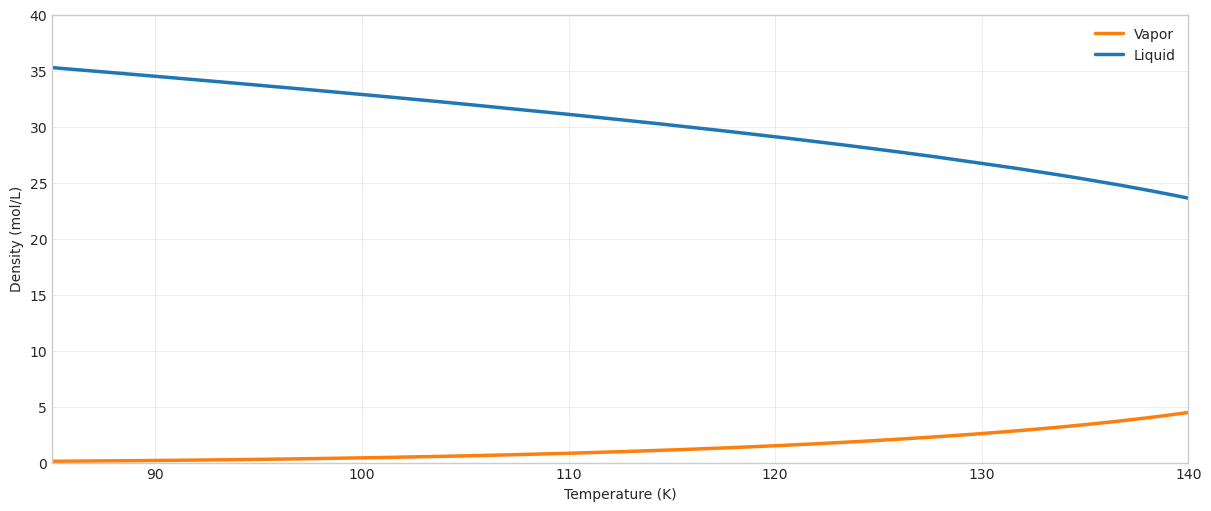

In [44]:
fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)

ax.plot(
    df["temperature_K"],
    df["density_vapor_mol_L"],
    color="tab:orange",
    linewidth=2.5,
    label="Vapor",
)
ax.plot(
    df["temperature_K"],
    df["density_liquid_mol_L"],
    color="tab:blue",
    linewidth=2.5,
    label="Liquid",
)

ax.set(
    xlabel="Temperature (K)",
    ylabel="Density (mol/L)",
    xlim=(df.temperature_K.min(), df.temperature_K.max()),
    ylim=(0, 40),
)
ax.legend()
ax.grid(True, alpha=0.35)
# fig.savefig("argon_liquid_vapor_density.png", dpi=300, bbox_inches="tight")
plt.show()

## Liquid-to-vapor density ratio

The ratio is dimensionless because both densities use the same units.

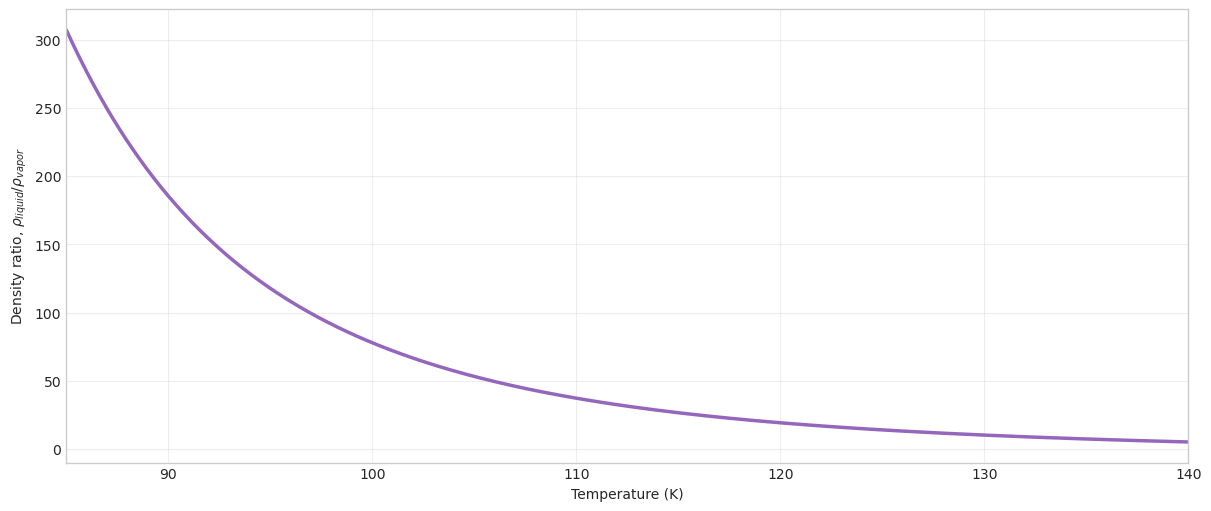

In [45]:
df["liquid_to_vapor_density_ratio"] = (
    df["density_liquid_mol_L"] / df["density_vapor_mol_L"]
)

fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
ax.plot(
    df["temperature_K"],
    df["liquid_to_vapor_density_ratio"],
    color="tab:purple",
    linewidth=2.5,
)
ax.set(
    xlabel="Temperature (K)",
    ylabel=r"Density ratio, $\rho_{liquid}/\rho_{vapor}$",
    xlim=(df.temperature_K.min(), df.temperature_K.max()),
)
ax.grid(True, alpha=0.35)
# Uncomment the next line if you prefer a logarithmic ratio axis.
# ax.set_yscale("log")
# fig.savefig("argon_liquid_to_vapor_density_ratio.png", dpi=300, bbox_inches="tight")
plt.show()

## Interpolate properties at a simulation temperature

The tabulated spacing is 0.1 K. This helper linearly interpolates every numeric property at any temperature inside the downloaded range.

In [46]:
def properties_at_temperature(temperature_K: float, table: pd.DataFrame = df) -> pd.Series:
    """Linearly interpolate every property at a temperature in kelvin."""
    temperatures = table["temperature_K"].to_numpy()
    if not temperatures[0] <= temperature_K <= temperatures[-1]:
        raise ValueError(
            f"temperature_K must be between {temperatures[0]} and {temperatures[-1]} K"
        )

    values = {
        column: np.interp(temperature_K, temperatures, table[column].to_numpy())
        for column in table.columns
    }
    return pd.Series(values, name=f"properties_at_{temperature_K:g}_K")

T_simulation = 100.0
properties_at_temperature(T_simulation)[[
    "pressure_bar",
    "density_liquid_kg_m3",
    "density_vapor_kg_m3",
    "surface_tension_N_m",
    "enthalpy_vaporization_kJ_mol",
]]

pressure_bar                       3.237700
density_liquid_kg_m3            1313.689980
density_vapor_kg_m3               16.858855
surface_tension_N_m                0.009478
enthalpy_vaporization_kJ_mol       6.010700
Name: properties_at_100_K, dtype: float64

## Export the cleaned table

Run this cell when you want a comma-separated version with the concise names and derived SI columns.

In [47]:
clean_path = Path("argon_saturation_clean.csv")
df.to_csv(clean_path, index=False)
print(f"Saved {len(df)} rows to {clean_path.resolve()}")

Saved 551 rows to /home/pnichols/MDsims/argon_saturation_clean.csv
